In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
gini = pd.read_csv("../data/gini_clean.csv")
gdp = pd.read_csv("../data/gdp_per_capita_clean.csv")
population = pd.read_csv("../data/population_clean.csv")

In [5]:
gini.shape


(2430, 5)

In [6]:
gdp.shape

(11764, 5)

In [7]:
population.shape

(14292, 5)

In [8]:
gini.columns

Index(['Country', 'Country_Code', 'Year', 'Gini', 'Region'], dtype='str')

In [9]:
gdp.columns

Index(['Country', 'Country_Code', 'Year', 'GDP_per_capita', 'Region'], dtype='str')

In [10]:
population.columns

Index(['Country', 'Country_Code', 'Year', 'Population', 'Region'], dtype='str')

In [11]:
master = gini.merge(
    gdp[["Country_Code", "Year", "GDP_per_capita"]],
    on=["Country_Code", "Year"],
    how="inner"
)

In [12]:
master.head

<bound method NDFrame.head of        Country Country_Code  Year  Gini                 Region  GDP_per_capita
0      Albania          ALB  2020  29.4  Europe & Central Asia     6027.913507
1      Albania          ALB  2019  30.1  Europe & Central Asia     6069.439031
2      Albania          ALB  2018  30.1  Europe & Central Asia     5897.654526
3      Albania          ALB  2017  33.1  Europe & Central Asia     5006.360130
4      Albania          ALB  2016  33.7  Europe & Central Asia     4457.634122
...        ...          ...   ...   ...                    ...             ...
2413    Zambia          ZMB  1993  52.6    Sub-Saharan Africa       390.916674
2414    Zambia          ZMB  1991  59.4    Sub-Saharan Africa       423.071257
2415  Zimbabwe          ZWE  2019  50.3    Sub-Saharan Africa      2184.521554
2416  Zimbabwe          ZWE  2017  44.3    Sub-Saharan Africa      3445.449410
2417  Zimbabwe          ZWE  2011  43.2    Sub-Saharan Africa      1037.775652

[2418 rows x 6 column

In [13]:
master = master.merge(
    population[["Country_Code", "Year", "Population"]],
    on=["Country_Code", "Year"],
    how="inner"
)

In [14]:
master.head()

,Country,Country_Code,Year,Gini,Region,GDP_per_capita,Population
0,Albania,ALB,2020,29.4,Europe & Central Asia,6027.913507,2528480.0
1,Albania,ALB,2019,30.1,Europe & Central Asia,6069.439031,2567801.0
2,Albania,ALB,2018,30.1,Europe & Central Asia,5897.654526,2607733.0
3,Albania,ALB,2017,33.1,Europe & Central Asia,5006.360130,2648285.0
4,Albania,ALB,2016,33.7,Europe & Central Asia,4457.634122,2689469.0


In [16]:
master.isnull().sum()

Country           0
Country_Code      0
Year              0
Gini              0
Region            0
GDP_per_capita    0
Population        0
dtype: int64

In [15]:
master.duplicated(
    subset=["Country_Code", "Year"]
).sum()

np.int64(0)

In [16]:
master = master.sort_values(
    ["Country", "Year"]
)

In [17]:
master.head(20)

,Country,Country_Code,Year,Gini,Region,GDP_per_capita,Population
11,Albania,ALB,1996,27.0,Europe & Central Asia,1020.976181,3168033.0
10,Albania,ALB,2002,31.7,Europe & Central Asia,1479.838846,3051010.0
9,Albania,ALB,2005,30.6,Europe & Central Asia,2741.721365,3011487.0
8,Albania,ALB,2008,30.0,Europe & Central Asia,4498.504868,2947314.0
7,Albania,ALB,2012,29.0,Europe & Central Asia,4280.933163,2860708.0
6,Albania,ALB,2014,34.6,Europe & Central Asia,4793.597511,2773767.0
5,Albania,ALB,2015,32.8,Europe & Central Asia,4199.539129,2731293.0
4,Albania,ALB,2016,33.7,Europe & Central Asia,4457.634122,2689469.0
3,Albania,ALB,2017,33.1,Europe & Central Asia,5006.360130,2648285.0
2,Albania,ALB,2018,30.1,Europe & Central Asia,5897.654526,2607733.0


In [20]:
master.to_csv(
    "../data/master_inequality_dataset.csv",
    index=False
)

In [18]:
master[[
    "Gini",
    "GDP_per_capita",
    "Population"
]].describe()

,Gini,GDP_per_capita,Population
count,2418.000000,2418.000000,2.418000e+03
mean,37.371754,15813.464484,5.169550e+07
std,8.701570,20746.029988,1.480236e+08
min,20.200000,120.734631,1.026700e+04
25%,30.900000,2257.421901,4.312614e+06
50%,35.300000,6506.018477,1.044013e+07
75%,42.600000,21992.003149,4.619544e+07
max,71.100000,134965.815442,1.425423e+09


In [22]:
master[["Gini", "GDP_per_capita"]].corr()

,Gini,GDP_per_capita
Gini,1.000000,-0.373598
GDP_per_capita,-0.373598,1.000000


In [19]:
master["Year"].min(), master["Year"].max()

(np.int64(1963), np.int64(2025))

In [20]:
master["Country"].nunique()

171

In [21]:
master["Country"].unique()

<ArrowStringArray>
[           'Albania',            'Algeria',             'Angola',
          'Argentina',            'Armenia',          'Australia',
            'Austria',         'Azerbaijan',         'Bangladesh',
           'Barbados',
 ...
      'United States',            'Uruguay',         'Uzbekistan',
            'Vanuatu',      'Venezuela, RB',           'Viet Nam',
 'West Bank and Gaza',        'Yemen, Rep.',             'Zambia',
           'Zimbabwe']
Length: 171, dtype: str

In [22]:
master["Country"].value_counts().head(10)

Country
United States     62
United Kingdom    54
Canada            46
Brazil            40
Costa Rica        39
Luxembourg        39
Italy             38
Argentina         36
France            33
Indonesia         33
Name: count, dtype: int64

In [24]:
master.nlargest(10, "Gini")

,Country,Country_Code,Year,Gini,Region,GDP_per_capita,Population
1543,Namibia,NAM,1993,71.1,Sub-Saharan Africa,2154.964737,1508697.0
1394,Malawi,MWI,1997,65.8,Sub-Saharan Africa,366.954461,10562035.0
1972,South Africa,ZAF,2005,65.0,Sub-Saharan Africa,5836.876633,49490033.0
1542,Namibia,NAM,2003,63.3,Sub-Saharan Africa,2569.247393,1917464.0
277,Brazil,BRA,1989,63.2,Latin America & Caribbean,2818.992780,146502972.0
1310,Lesotho,LSO,1994,63.0,Sub-Saharan Africa,455.593586,1927707.0
1971,South Africa,ZAF,2008,62.5,Sub-Saharan Africa,6184.754743,51114599.0
230,Bolivia,BOL,2000,61.6,Latin America & Caribbean,975.777060,8606326.0
243,Botswana,BWA,2002,61.5,Sub-Saharan Africa,3117.250872,1744763.0
278,Brazil,BRA,1988,61.4,Latin America & Caribbean,2140.650276,143826357.0


In [25]:
country_gini = (
    master.groupby("Country")
    .agg(
        Average_Gini=("Gini", "mean"),
        Average_GDP=("GDP_per_capita", "mean"),
        Population=("Population", "mean"),
        Observations=("Gini", "count")
    )
    .reset_index()
)

In [26]:
country_gini.head()

,Country,Average_Gini,Average_GDP,Population,Observations
0,Albania,31.008333,4206.176032,2.798782e+06,12
1,Algeria,33.433333,3278.044711,2.982770e+07,3
2,Angola,48.633333,2677.906461,2.302356e+07,3
3,Argentina,45.466667,8535.240039,3.920832e+07,36
4,Armenia,31.726923,3346.891817,3.064239e+06,26


In [27]:
top_10_inequality = country_gini.nlargest(
    10, "Average_Gini"
)

top_10_inequality

,Country,Average_Gini,Average_GDP,Population,Observations
106,Namibia,63.625000,3450.308095,1.969464e+06,4
136,South Africa,59.885714,5714.795773,5.162554e+07,7
17,Botswana,57.520000,3652.887328,1.696154e+06,5
18,Brazil,56.015000,5969.085035,1.759580e+08,40
12,Belize,55.450000,4278.911469,2.330449e+05,8
46,Eswatini,54.450000,2379.751827,1.066822e+06,4
29,Colombia,54.086667,4743.323252,4.304187e+07,30
85,Lesotho,53.775000,526.314857,1.936408e+06,4
63,Honduras,53.237500,1581.622545,7.557771e+06,32
116,Panama,53.203333,8675.546868,3.456009e+06,30


In [28]:
bottom_10_inequality = country_gini.nsmallest(
    10, "Average_Gini"
)

bottom_10_inequality

,Country,Average_Gini,Average_GDP,Population,Observations
134,Slovenia,25.396154,21062.284033,2.042188e+06,26
133,Slovak Republic,25.454545,15935.231133,5.405706e+06,22
37,Czechia,25.887500,18445.304025,1.046688e+07,24
38,Denmark,26.904000,53640.839358,5.571689e+06,25
49,Finland,26.948000,43021.369069,5.356849e+06,25
114,Norway,27.142308,73906.721209,4.896184e+06,26
143,Sweden,27.372414,44800.325135,9.396447e+06,29
66,India,27.537500,822.257810,1.019673e+09,8
10,Belarus,27.588000,4388.259528,9.664261e+06,25
158,Ukraine,27.654167,2399.506785,4.752671e+07,24


In [29]:
region_gini = (
    master.groupby("Region")["Gini"]
    .mean()
    .sort_values(ascending=False)
)

region_gini

Region
Latin America & Caribbean                            49.050000
Sub-Saharan Africa                                   43.403376
East Asia & Pacific                                  36.725943
North America                                        36.312037
Middle East, North Africa, Afghanistan & Pakistan    35.377465
South Asia                                           32.982927
Europe & Central Asia                                31.749233
Name: Gini, dtype: float64

In [30]:
india = master[
    master["Country"] == "India"
].sort_values("Year")

In [31]:
india[[
    "Year",
    "Gini",
    "GDP_per_capita",
    "Population"
]]

,Year,Gini,GDP_per_capita,Population
1011,1977,29.7,189.585569,6.408011e+08
1010,1983,27.2,295.999773,7.373727e+08
1009,1987,27.5,344.941028,8.089313e+08
1008,1993,26.1,302.884806,9.221184e+08
1007,2004,27.7,624.258827,1.135992e+09
1006,2009,27.8,1094.949746,1.225525e+09
1005,2011,28.8,1445.461275,1.261225e+09
1004,2022,25.5,2279.981457,1.425423e+09


In [32]:
india[["Year", "Gini"]]

,Year,Gini
1011,1977,29.7
1010,1983,27.2
1009,1987,27.5
1008,1993,26.1
1007,2004,27.7
1006,2009,27.8
1005,2011,28.8
1004,2022,25.5


In [33]:
correlation = master[
    ["Gini", "GDP_per_capita"]
].corr().loc[
    "Gini", "GDP_per_capita"
]

correlation

np.float64(-0.37359836424712994)

In [34]:
import numpy as np

In [35]:
master["Log_GDP_per_capita"] = np.log1p(
    master["GDP_per_capita"]
)

In [36]:
master[
    ["Gini", "Log_GDP_per_capita"]
].corr()

,Gini,Log_GDP_per_capita
Gini,1.000000,-0.367044
Log_GDP_per_capita,-0.367044,1.000000


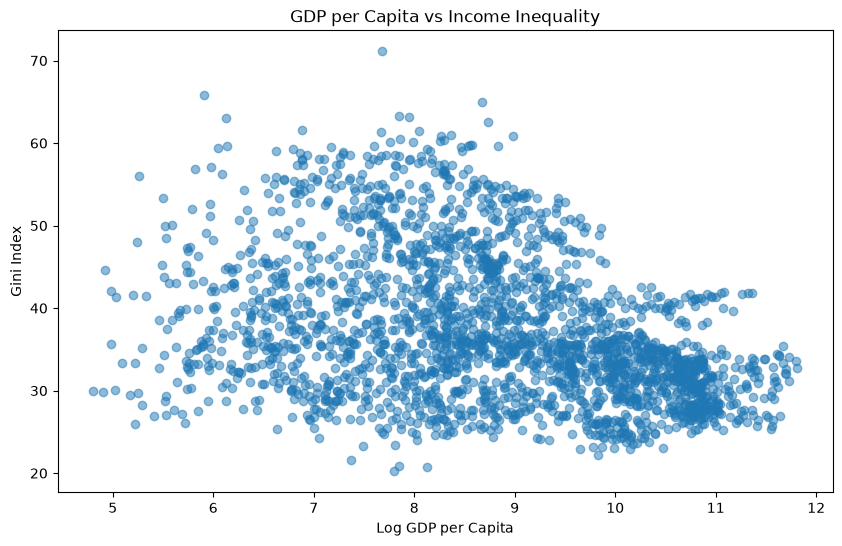

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    master["Log_GDP_per_capita"],
    master["Gini"],
    alpha=0.5
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Gini Index")
plt.title("GDP per Capita vs Income Inequality")

plt.show()

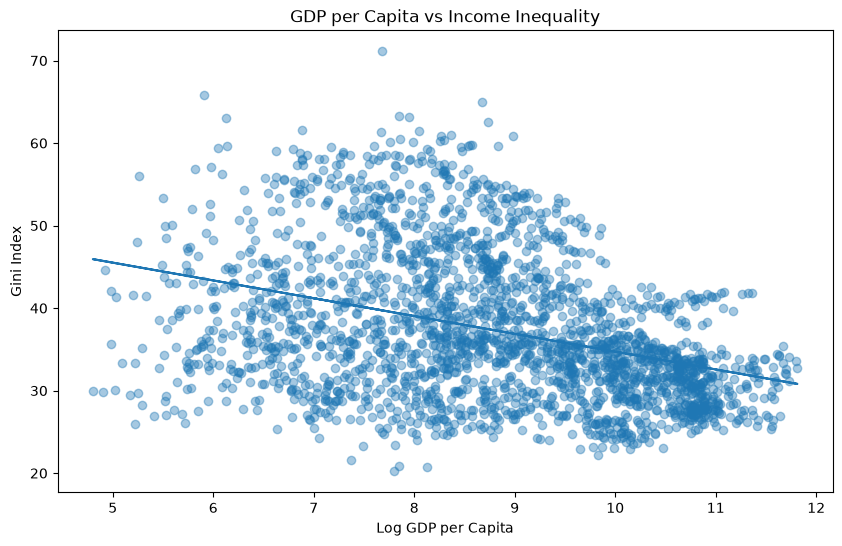

In [39]:
import numpy as np

x = master["Log_GDP_per_capita"]
y = master["Gini"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.4
)

plt.plot(
    x,
    slope * x + intercept
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Gini Index")
plt.title("GDP per Capita vs Income Inequality")

plt.show()

In [40]:
correlation = master[
    ["Gini", "Log_GDP_per_capita"]
].corr().loc[
    "Gini", "Log_GDP_per_capita"
]

print("Correlation:", correlation)

Correlation: -0.3670443674210569


In [41]:
india = master[
    master["Country"] == "India"
]

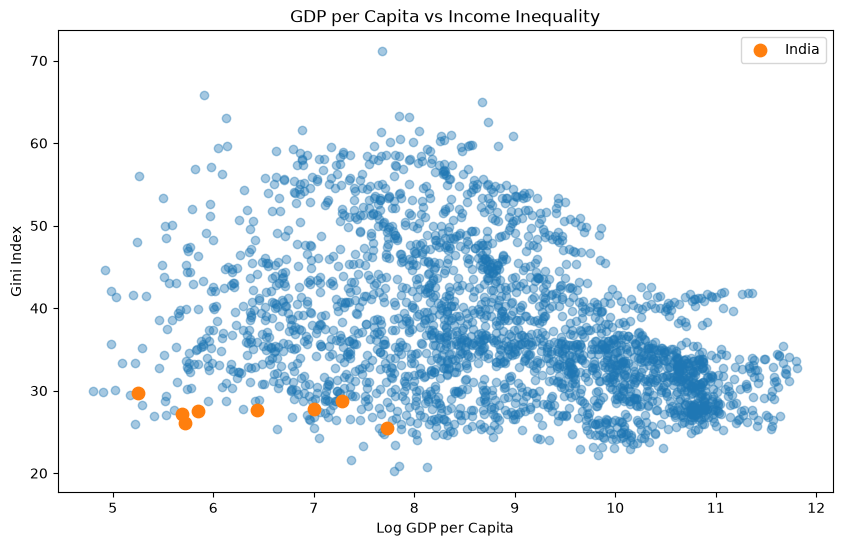

In [42]:
plt.figure(figsize=(10, 6))

plt.scatter(
    master["Log_GDP_per_capita"],
    master["Gini"],
    alpha=0.4
)

plt.scatter(
    india["Log_GDP_per_capita"],
    india["Gini"],
    s=80,
    label="India"
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Gini Index")
plt.title("GDP per Capita vs Income Inequality")
plt.legend()

plt.show()

In [43]:
latest_year = master["Year"].max()

print("Latest year:", latest_year)

Latest year: 2025


In [44]:
latest_data = master[
    master["Year"] == latest_year
].copy()

In [45]:
latest_data.shape

(4, 8)

In [46]:
latest_data[
    ["Country", "Country_Code", "Gini"]
].head(20)

,Country,Country_Code,Gini
463,Costa Rica,CRI,45.5
638,Ecuador,ECU,45.9
1012,Indonesia,IDN,34.4
2356,Uzbekistan,UZB,32.7


In [48]:
fig = px.choropleth(
    latest_data,
    locations="Country_Code",
    color="Gini",
    hover_name="Country",
    hover_data=["Gini"],
    color_continuous_scale="RdBu_r",
    title=f"Global Income Inequality — {latest_year}",
    labels={"Gini": "Gini Index"}
)

fig.show()

In [49]:
india = master[
    master["Country"] == "India"
].sort_values("Year")

In [50]:
fig = px.line(
    india,
    x="Year",
    y="Gini",
    markers=True,
    title="India — Gini Index Over Time",
    labels={
        "Gini": "Gini Index",
        "Year": "Year"
    }
)

fig.show()

In [53]:
country = "Germany"
country_data = master[
    master["Country"] == country
].sort_values("Year")
fig = px.line(
    country_data,
    x="Year",
    y="Gini",
    markers=True,
    title=f"{country} — Gini Index Over Time"
)

fig.show()

In [55]:
top10 = country_gini.nlargest(
    10,
    "Average_Gini"
).sort_values("Average_Gini")

fig = px.bar(
    top10,
    x="Average_Gini",
    y="Country",
    orientation="h",
    title="Top 10 Countries by Average Gini Index",
    labels={
        "Average_Gini": "Average Gini Index",
        "Country": "Country"
    }
)

fig.show()

In [56]:
regional_correlation = (
    master
    .groupby("Region")
    .apply(
        lambda x: x["Gini"].corr(
            x["Log_GDP_per_capita"]
        )
    )
    .sort_values()
)

regional_correlation

Region
Latin America & Caribbean                           -0.426054
Europe & Central Asia                               -0.211140
East Asia & Pacific                                 -0.108908
Middle East, North Africa, Afghanistan & Pakistan    0.038103
Sub-Saharan Africa                                   0.170055
North America                                        0.275335
South Asia                                           0.328181
dtype: float64

In [57]:
india[[
    "Year",
    "Gini",
    "GDP_per_capita"
]]

,Year,Gini,GDP_per_capita
1011,1977,29.7,189.585569
1010,1983,27.2,295.999773
1009,1987,27.5,344.941028
1008,1993,26.1,302.884806
1007,2004,27.7,624.258827
1006,2009,27.8,1094.949746
1005,2011,28.8,1445.461275
1004,2022,25.5,2279.981457


In [58]:
india[
    ["Gini", "GDP_per_capita"]
].corr()

,Gini,GDP_per_capita
Gini,1.000000,-0.369876
GDP_per_capita,-0.369876,1.000000


In [ ]:
sorted(master["Year"].unique())